# Data Cleaning

## Create data manifest

In [ ]:
old_data_path = "/srv/defectDetectionDataset/surface_old_cleaned"
new_data_path = "/srv/defectDetectionDataset/data_collection/ats"

import os
import pandas as pd
from hashlib import md5

old_images = []

extensions = [".png", ".jpg", ".jpeg"]

for dirpath, dirnames, filenames in os.walk(old_data_path):
    for filename in filenames:
        if any(filename.endswith(ext) for ext in extensions):
            file_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            image_id = md5(file_path.encode()).hexdigest()
            old_images.append({"image_id": image_id, "file_path": file_path, "label": label, "source": "old", "session_id": "unknown"})


new_images = []

for dirpath, dirnames, filenames in os.walk(new_data_path):
    for filename in filenames:
        if any(filename.endswith(ext) for ext in extensions):
            file_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            session_id = os.path.basename(os.path.dirname(dirpath))
            image_id = md5(file_path.encode()).hexdigest()
            new_images.append({"image_id": image_id, "file_path": file_path, "label": label, "source": "new", "session_id": session_id})

all_images = old_images + new_images
df = pd.DataFrame(all_images)

In [6]:
print(f"Number of old images: {len(old_images)}")
print(f"Number of new images: {len(new_images)}")

Number of old images: 4639
Number of new images: 861


In [8]:
os.makedirs("artifacts", exist_ok=True)
df.to_csv("artifacts/data_manifest.csv", index=False)

## Find exact duplicates by file hashes

### Duplicates in old data

In [9]:
from PIL import Image

old_images_df = df[df["source"] == "old"]
old_images_hashes = []

for sample in old_images_df.itertuples():
    img = Image.open(sample.file_path)
    hash = md5(img.tobytes()).hexdigest()
    old_images_hashes.append({"image_id": sample.image_id, "hash": hash})

old_images_hashes_df = pd.DataFrame(old_images_hashes)
old_images_hashes_df.to_csv("artifacts/old_image_hashes.csv", index=False)

In [10]:
# Find duplicates in old data
same_hashes = old_images_hashes_df.groupby("hash")["image_id"].apply(list).to_dict()
hash_with_duplicates = {hash: ids for hash, ids in same_hashes.items() if len(ids) > 1}

manifest_df = pd.read_csv("artifacts/data_manifest.csv")

if "is_duplicate" not in manifest_df.columns:
    manifest_df["is_duplicate"] = False
    
for hash, image_ids in hash_with_duplicates.items():
    manifest_df.loc[manifest_df["image_id"] == image_ids[0], "is_duplicate"] = False
    for image_id in image_ids[1:]:
        manifest_df.loc[manifest_df["image_id"] == image_id, "is_duplicate"] = True

manifest_df.to_csv("artifacts/data_manifest.csv", index=False)
print(f"Found {len(hash_with_duplicates)} hashes with duplicates in old data")
print(f"Total duplicate images marked: {manifest_df['is_duplicate'].sum()}")


Found 36 hashes with duplicates in old data
Total duplicate images marked: 36


### Duplicates in new data

In [11]:
new_images_df = df[df["source"] == "new"]
new_images_hashes = []

for sample in new_images_df.itertuples():
    img = Image.open(sample.file_path)
    hash = md5(img.tobytes()).hexdigest()
    new_images_hashes.append({"image_id": sample.image_id, "hash": hash})

new_images_hashes_df = pd.DataFrame(new_images_hashes)
new_images_hashes_df.to_csv("artifacts/new_image_hashes.csv", index=False)

In [12]:
# Find duplicates in new data
same_hashes = new_images_hashes_df.groupby("hash")["image_id"].apply(list).to_dict()
hash_with_duplicates = {hash: ids for hash, ids in same_hashes.items() if len(ids) > 1}

manifest_df = pd.read_csv("artifacts/data_manifest.csv")

if "is_duplicate" not in manifest_df.columns:
    manifest_df["is_duplicate"] = False
    
for hash, image_ids in hash_with_duplicates.items():
    manifest_df.loc[manifest_df["image_id"] == image_ids[0], "is_duplicate"] = False
    for image_id in image_ids[1:]:
        manifest_df.loc[manifest_df["image_id"] == image_id, "is_duplicate"] = True

manifest_df.to_csv("artifacts/data_manifest.csv", index=False)
print(f"Found {len(hash_with_duplicates)} hashes with duplicates in new data")
print(f"Total duplicate images marked in old and new: {manifest_df['is_duplicate'].sum()}")

Found 0 hashes with duplicates in new data
Total duplicate images marked in old and new: 36


## Find near duplicates with pretrained Blip2 model

In [13]:
import torch
from torchvision import models
from torchvision.transforms import v2
import numpy as np

# Option 1: MobileNetV3-Large (lightweight, no download needed)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load MobileNetV3-Large with pretrained weights
weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
model = models.mobilenet_v3_large(weights=weights)
model.eval()
model.to(device)

# Define transforms
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transform = v2.Compose([
    v2.Resize(480, antialias=True),
    v2.CenterCrop(480),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

# Get old images excluding duplicates
manifest_df = pd.read_csv("artifacts/data_manifest.csv")
old_non_duplicate_df = manifest_df[(manifest_df["source"] == "old") & (manifest_df["is_duplicate"] == False)]

# Generate embeddings for old images
old_embeddings = []

@torch.no_grad()
def get_mobilenet_embedding(model, img_tensor):
    """Extract features from MobileNetV3 before classifier"""
    feats = model.features(img_tensor)
    feats = model.avgpool(feats)
    feats = torch.flatten(feats, 1)
    return torch.nn.functional.normalize(feats, dim=1)

for idx, row in old_non_duplicate_df.iterrows():
    img = Image.open(row["file_path"]).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    embedding = get_mobilenet_embedding(model, img_tensor)
    embedding = embedding.cpu().numpy().flatten()
    
    old_embeddings.append({
        "image_id": row["image_id"],
        "embedding": embedding
    })
    
    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1}/{len(old_non_duplicate_df)} old images")

# Save embeddings
embeddings_array = np.array([e["embedding"] for e in old_embeddings])
image_ids = [e["image_id"] for e in old_embeddings]

np.save("artifacts/old_image_embeddings.npy", embeddings_array)
pd.DataFrame({"image_id": image_ids}).to_csv("artifacts/old_image_embeddings_ids.csv", index=False)

print(f"Generated embeddings for {len(old_embeddings)} old images")
print(f"Embedding shape: {embeddings_array.shape}")

# ----------------------------------------------------------
# Option 2: BLIP2 (more accurate, requires download)
# Uncomment below to use BLIP2 instead of MobileNetV3
# ----------------------------------------------------------
# from transformers import Blip2Processor, Blip2Model
# 
# device = "cuda" if torch.cuda.is_available() else "cpu"
# processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
# model = Blip2Model.from_pretrained("Salesforce/blip2-opt-2.7b").to(device)
# 
# manifest_df = pd.read_csv("artifacts/data_manifest.csv")
# old_non_duplicate_df = manifest_df[(manifest_df["source"] == "old") & (manifest_df["is_duplicate"] == False)]
# 
# old_embeddings = []
# 
# for idx, row in old_non_duplicate_df.iterrows():
#     img = Image.open(row["file_path"]).convert("RGB")
#     inputs = processor(images=img, return_tensors="pt").to(device)
#     
#     with torch.no_grad():
#         image_features = model.get_image_features(**inputs)
#     
#     embedding = image_features.cpu().numpy().flatten()
#     old_embeddings.append({
#         "image_id": row["image_id"],
#         "embedding": embedding
#     })
#     
#     if (idx + 1) % 100 == 0:
#         print(f"Processed {idx + 1}/{len(old_non_duplicate_df)} old images")
# 
# embeddings_array = np.array([e["embedding"] for e in old_embeddings])
# image_ids = [e["image_id"] for e in old_embeddings]
# 
# np.save("artifacts/old_image_embeddings.npy", embeddings_array)
# pd.DataFrame({"image_id": image_ids}).to_csv("artifacts/old_image_embeddings_ids.csv", index=False)
# 
# print(f"Generated embeddings for {len(old_embeddings)} old images")
# print(f"Embedding shape: {embeddings_array.shape}")

Processed 100/4603 old images
Processed 200/4603 old images
Processed 300/4603 old images
Processed 400/4603 old images
Processed 500/4603 old images
Processed 600/4603 old images
Processed 700/4603 old images
Processed 800/4603 old images
Processed 900/4603 old images
Processed 1000/4603 old images
Processed 1100/4603 old images
Processed 1200/4603 old images
Processed 1300/4603 old images
Processed 1400/4603 old images
Processed 1500/4603 old images
Processed 1600/4603 old images
Processed 1700/4603 old images
Processed 1800/4603 old images
Processed 1900/4603 old images
Processed 2000/4603 old images
Processed 2100/4603 old images
Processed 2200/4603 old images
Processed 2300/4603 old images
Processed 2400/4603 old images
Processed 2500/4603 old images
Processed 2600/4603 old images
Processed 2700/4603 old images
Processed 2800/4603 old images
Processed 2900/4603 old images
Processed 3000/4603 old images
Processed 3100/4603 old images
Processed 3200/4603 old images
Processed 3300/46

In [14]:
# Load embeddings

embeddings_array = np.load("artifacts/old_image_embeddings.npy")
image_ids_df = pd.read_csv("artifacts/old_image_embeddings_ids.csv")
image_ids = image_ids_df["image_id"].tolist()
embeddings_dict = {image_id: embeddings_array[idx] for idx, image_id in enumerate(image_ids)}

# build faiss index

import faiss

dimension = embeddings_array.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings_array)
print(f"FAISS index built with {index.ntotal} vectors of dimension {dimension}")

# search for 20 nearest neighbors
k = 20
D, I = index.search(embeddings_array, k)
D, I = torch.from_numpy(D), torch.from_numpy(I)#
# D: distances, I: indices of nearest neighbors

FAISS index built with 4603 vectors of dimension 960


In [15]:
from shutil import copy2

high_threshold = 0.99
medium_threshold = 0.93
low_threshold = 0.87


# Calculate cosine similarity from L2 distances
# Convert L2 distance to cosine similarity: similarity = 1 - (L2_distance^2 / 2)
similarities = 1 - (D ** 2 / 2)

# Create similarity pairs with image IDs
similarity_pairs = []
for i in range(len(similarities)):
    for j in range(1, k):  # Skip first neighbor (itself)
        img_id_1 = image_ids[i]
        img_id_2 = image_ids[I[i][j].item()]
        sim_score = similarities[i][j].item()
        similarity_pairs.append({
            "image_id_1": img_id_1,
            "image_id_2": img_id_2,
            "similarity": sim_score
        })

similarity_df = pd.DataFrame(similarity_pairs)

# Save all similarity pairs to CSV
similarity_df.to_csv("artifacts/similarity_pairs.csv", index=False)
print(f"Saved {len(similarity_df)} similarity pairs to artifacts/similarity_pairs.csv")

# Filter by thresholds
high_sim = similarity_df[similarity_df["similarity"] >= high_threshold]
medium_sim = similarity_df[(similarity_df["similarity"] >= medium_threshold) & 
                           (similarity_df["similarity"] < high_threshold)]
low_sim = similarity_df[(similarity_df["similarity"] >= low_threshold) & 
                        (similarity_df["similarity"] < medium_threshold)]

print(f"High similarity pairs (>= {high_threshold}): {len(high_sim)}")
print(f"Medium similarity pairs ({medium_threshold} - {high_threshold}): {len(medium_sim)}")
print(f"Low similarity pairs ({low_threshold} - {medium_threshold}): {len(low_sim)}")

# Sample 150 pairs from each category
n_samples = min(150, len(high_sim), len(medium_sim), len(low_sim))
high_sample = high_sim.sample(n=min(n_samples, len(high_sim)), random_state=42)
medium_sample = medium_sim.sample(n=min(n_samples, len(medium_sim)), random_state=42)
low_sample = low_sim.sample(n=min(n_samples, len(low_sim)), random_state=42)

# Create output directory
output_dir = "/home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/cluster_samples"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/high", exist_ok=True)
os.makedirs(f"{output_dir}/medium", exist_ok=True)
os.makedirs(f"{output_dir}/low", exist_ok=True)

# Copy sampled image pairs and create pair manifest

def copy_pair(row, idx, category):
    img1_path = manifest_df[manifest_df["image_id"] == row["image_id_1"]]["file_path"].values[0]
    img2_path = manifest_df[manifest_df["image_id"] == row["image_id_2"]]["file_path"].values[0]
    
    ext1 = os.path.splitext(img1_path)[1]
    ext2 = os.path.splitext(img2_path)[1]
    
    copy2(img1_path, f"{output_dir}/{category}/pair_{idx:03d}_img1{ext1}")
    copy2(img2_path, f"{output_dir}/{category}/pair_{idx:03d}_img2{ext2}")

# Create manifest for sampled pairs
sampled_pairs = []
pair_counter = 0

for idx, row in high_sample.iterrows():
    copy_pair(row, pair_counter, "high")
    sampled_pairs.append({
        "pair_id": f"high_pair_{pair_counter:03d}",
        "image_id_a": row["image_id_1"],
        "image_id_b": row["image_id_2"],
        "similarity": row["similarity"],
        "category": "high"
    })
    pair_counter += 1

pair_counter = 0
for idx, row in medium_sample.iterrows():
    copy_pair(row, pair_counter, "medium")
    sampled_pairs.append({
        "pair_id": f"medium_pair_{pair_counter:03d}",
        "image_id_a": row["image_id_1"],
        "image_id_b": row["image_id_2"],
        "similarity": row["similarity"],
        "category": "medium"
    })
    pair_counter += 1

pair_counter = 0
for idx, row in low_sample.iterrows():
    copy_pair(row, pair_counter, "low")
    sampled_pairs.append({
        "pair_id": f"low_pair_{pair_counter:03d}",
        "image_id_a": row["image_id_1"],
        "image_id_b": row["image_id_2"],
        "similarity": row["similarity"],
        "category": "low"
    })
    pair_counter += 1

# Save sampled pairs manifest
sampled_pairs_df = pd.DataFrame(sampled_pairs)
sampled_pairs_df.to_csv(f"{output_dir}/sampled_pairs.csv", index=False)

print(f"Copied {len(high_sample)} high similarity pairs")
print(f"Copied {len(medium_sample)} medium similarity pairs")
print(f"Copied {len(low_sample)} low similarity pairs")
print(f"Saved sampled pairs manifest to {output_dir}/sampled_pairs.csv")

Saved 87457 similarity pairs to artifacts/similarity_pairs.csv
High similarity pairs (>= 0.99): 8336
Medium similarity pairs (0.93 - 0.99): 60933
Low similarity pairs (0.87 - 0.93): 14437
Copied 150 high similarity pairs
Copied 150 medium similarity pairs
Copied 150 low similarity pairs
Saved sampled pairs manifest to /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/cluster_samples/sampled_pairs.csv


## Threshold Analysis: Precision and Recall

In [24]:
# Load labeled data
labels_df = pd.read_csv("artifacts/cluster_samples/labels.csv")

print(f"Total labeled pairs: {len(labels_df)}")
print(f"\nLabel distribution:")
print(labels_df["label"].value_counts())

# Define positive (duplicates) and negative (not duplicates) classes
positive_labels = {"EXACT", "SAME_INSTANCE"}
negative_labels = {"DIFF_INSTANCE"}

# Add binary classification column
labels_df["is_duplicate"] = labels_df["label"].isin(positive_labels)

print(f"\nPositive samples (EXACT/SAME_INSTANCE): {labels_df['is_duplicate'].sum()}")
print(f"Negative samples (DIFF_INSTANCE): {(~labels_df['is_duplicate']).sum()}")

Total labeled pairs: 450

Label distribution:
label
DIFF_INSTANCE    199
SAME_INSTANCE    180
AMBIGUOUS         65
EXACT              6
Name: count, dtype: int64

Positive samples (EXACT/SAME_INSTANCE): 186
Negative samples (DIFF_INSTANCE): 264


In [25]:
# Sweep through multiple thresholds and calculate precision/recall
import numpy as np

# Define threshold range
thresholds = np.arange(0.90, 1.0, 0.005)

results = []

for threshold in thresholds:
    # Predict: if similarity >= threshold, predict as duplicate (positive)
    labels_df["predicted_duplicate"] = labels_df["similarity"] >= threshold
    
    # Calculate confusion matrix components
    tp = ((labels_df["predicted_duplicate"] == True) & (labels_df["is_duplicate"] == True)).sum()
    fp = ((labels_df["predicted_duplicate"] == True) & (labels_df["is_duplicate"] == False)).sum()
    tn = ((labels_df["predicted_duplicate"] == False) & (labels_df["is_duplicate"] == False)).sum()
    fn = ((labels_df["predicted_duplicate"] == False) & (labels_df["is_duplicate"] == True)).sum()
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / len(labels_df)
    
    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "accuracy": accuracy,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn
    })

results_df = pd.DataFrame(results)
results_df.to_csv("artifacts/threshold_analysis.csv", index=False)

print(f"Analyzed {len(thresholds)} thresholds")
print(f"\nBest F1 score: {results_df['f1_score'].max():.4f} at threshold {results_df.loc[results_df['f1_score'].idxmax(), 'threshold']:.4f}")
print(f"Best precision: {results_df['precision'].max():.4f} at threshold {results_df.loc[results_df['precision'].idxmax(), 'threshold']:.4f}")
print(f"Best recall: {results_df['recall'].max():.4f} at threshold {results_df.loc[results_df['recall'].idxmax(), 'threshold']:.4f}")

# Display top 10 results by F1 score
print("\nTop 10 thresholds by F1 score:")
print(results_df.nlargest(10, "f1_score")[["threshold", "precision", "recall", "f1_score", "accuracy"]])

Analyzed 20 thresholds

Best F1 score: 0.7940 at threshold 0.9650
Best precision: 0.9516 at threshold 0.9950
Best recall: 0.9946 at threshold 0.9000

Top 10 thresholds by F1 score:
    threshold  precision    recall  f1_score  accuracy
13      0.965   0.737327  0.860215  0.794045  0.815556
14      0.970   0.741627  0.833333  0.784810  0.811111
12      0.960   0.703863  0.881720  0.782816  0.797778
17      0.985   0.849057  0.725806  0.782609  0.833333
11      0.955   0.688525  0.903226  0.781395  0.791111
16      0.980   0.816568  0.741935  0.777465  0.824444
18      0.990   0.866667  0.698925  0.773810  0.831111
15      0.975   0.761905  0.774194  0.768000  0.806667
10      0.950   0.656489  0.924731  0.767857  0.768889
9       0.945   0.650376  0.930108  0.765487  0.764444


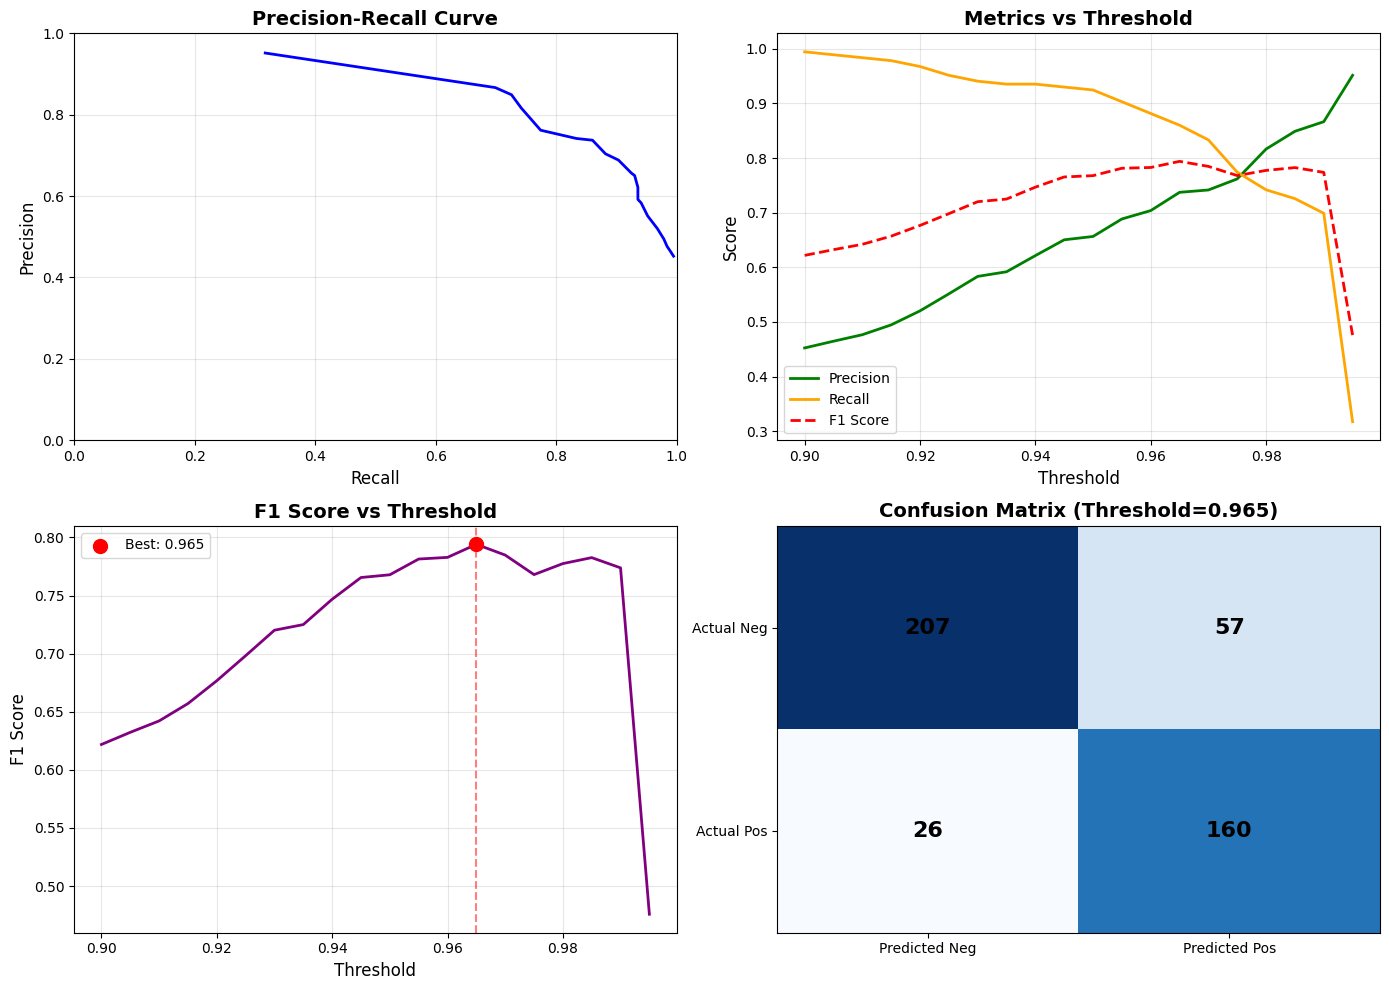


Plots saved to artifacts/threshold_analysis.png


In [26]:
# Plot Precision-Recall curve and other metrics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Precision-Recall curve
axes[0, 0].plot(
    results_df["recall"], results_df["precision"], linewidth=2, color="blue"
)
axes[0, 0].set_xlabel("Recall", fontsize=12)
axes[0, 0].set_ylabel("Precision", fontsize=12)
axes[0, 0].set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim([0, 1])
axes[0, 0].set_ylim([0, 1])

# 2. Precision and Recall vs Threshold
axes[0, 1].plot(
    results_df["threshold"],
    results_df["precision"],
    label="Precision",
    linewidth=2,
    color="green",
)
axes[0, 1].plot(
    results_df["threshold"],
    results_df["recall"],
    label="Recall",
    linewidth=2,
    color="orange",
)
axes[0, 1].plot(
    results_df["threshold"],
    results_df["f1_score"],
    label="F1 Score",
    linewidth=2,
    color="red",
    linestyle="--",
)
axes[0, 1].set_xlabel("Threshold", fontsize=12)
axes[0, 1].set_ylabel("Score", fontsize=12)
axes[0, 1].set_title("Metrics vs Threshold", fontsize=14, fontweight="bold")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. F1 Score vs Threshold (zoomed)
axes[1, 0].plot(
    results_df["threshold"], results_df["f1_score"], linewidth=2, color="purple"
)
best_f1_idx = results_df["f1_score"].idxmax()
best_threshold = results_df.loc[best_f1_idx, "threshold"]
best_f1 = results_df.loc[best_f1_idx, "f1_score"]
axes[1, 0].scatter(
    [best_threshold],
    [best_f1],
    color="red",
    s=100,
    zorder=5,
    label=f"Best: {best_threshold:.3f}",
)
axes[1, 0].axvline(x=best_threshold, color="red", linestyle="--", alpha=0.5)
axes[1, 0].set_xlabel("Threshold", fontsize=12)
axes[1, 0].set_ylabel("F1 Score", fontsize=12)
axes[1, 0].set_title("F1 Score vs Threshold", fontsize=14, fontweight="bold")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Confusion Matrix counts at best threshold
best_result = results_df.iloc[best_f1_idx]
confusion_data = [
    [best_result["tn"], best_result["fp"]],
    [best_result["fn"], best_result["tp"]],
]
im = axes[1, 1].imshow(confusion_data, cmap="Blues", aspect="auto")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(["Predicted Neg", "Predicted Pos"])
axes[1, 1].set_yticklabels(["Actual Neg", "Actual Pos"])
axes[1, 1].set_title(
    f"Confusion Matrix (Threshold={best_threshold:.3f})", fontsize=14, fontweight="bold"
)

# Add text annotations
for i in range(2):
    for j in range(2):
        text = axes[1, 1].text(
            j,
            i,
            int(confusion_data[i][j]),
            ha="center",
            va="center",
            color="black",
            fontsize=16,
            fontweight="bold",
        )

plt.tight_layout()
plt.savefig("artifacts/threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPlots saved to artifacts/threshold_analysis.png")

ROC AUC Score: 0.8930


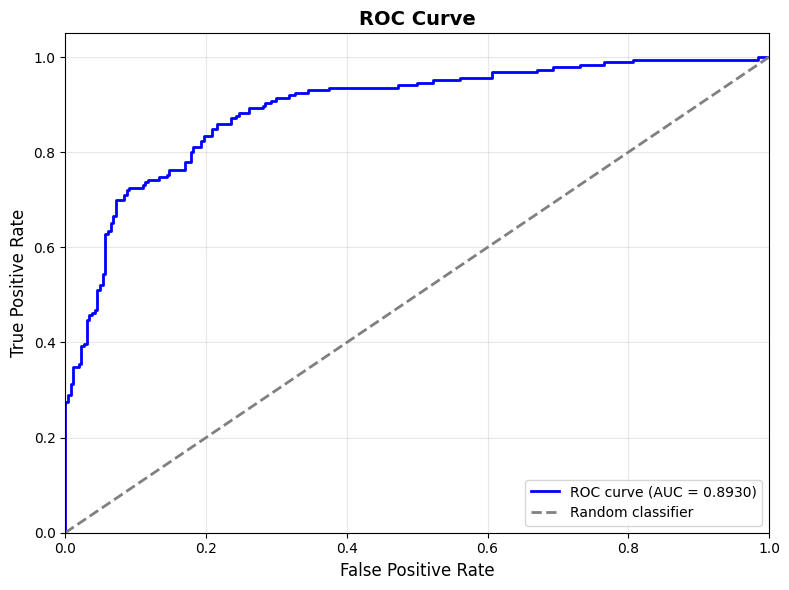


ROC curve saved to artifacts/roc_curve.png

Classification Performance Summary:
ROC AUC: 0.8930
Best F1 Score: 0.7940
Best Threshold: 0.9650


In [27]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC

# Get true labels and predicted scores
y_true = labels_df["is_duplicate"].values
y_scores = labels_df["similarity"].values

# Calculate ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nROC curve saved to artifacts/roc_curve.png")

# Add ROC AUC to results summary
print(f"\nClassification Performance Summary:")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Best F1 Score: {results_df['f1_score'].max():.4f}")
print(f"Best Threshold: {results_df.loc[results_df['f1_score'].idxmax(), 'threshold']:.4f}")